In [1]:
from tensorboard_logger import Logger as TbLogger

In [1]:
from tqdm import tqdm
import os

filename = "data/tsp/tsp10-200_concorde.txt"
# filename = "data/tsp/tsp10-200_omer_test_2.txt"


# Get the total number of lines in the file without iteration
with open(filename, "r") as file:
    total_lines = sum(1 for _ in file)

print(f"Total lines in the file: {total_lines}")


Total lines in the file: 25600


In [2]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
    def distance(self, other):
        return ((self.x - other.x) ** 2 + (self.y - other.y) ** 2) ** 0.5

In [3]:
import pandas as pd

num_nodes_col = []
tour_length_col = []

offset = 1280 * 19

# for line in open(filename, "r").readlines()[offset:(offset + 1280)]:
for line in open(filename, "r").readlines():
    line = line.split(" ")
    num_nodes = int(line.index('output') // 2)
    cities_points = [Point(float(line[idx]), float(line[idx + 1])) for idx in range(0, 2 * num_nodes, 2)]
    tour_nodes = [int(node) - 1 for node in line[line.index('output') + 1:-1]]

    tour_length = sum(
        cities_points[tour_nodes[i]].distance(cities_points[tour_nodes[i + 1]])
        for i in range(len(tour_nodes) - 1)
    )
    
    num_nodes_col.append(num_nodes)
    tour_length_col.append(tour_length)


base_df = pd.DataFrame({
    "num_nodes": num_nodes_col,
    "tour_length": tour_length_col,
})
base_df

,num_nodes,tour_length
0,10,2.761457
1,10,2.858019
2,10,3.288704
3,10,2.780503
4,10,2.688265
...,...,...
25595,200,10.687935
25596,200,10.624868
25597,200,11.219512
25598,200,11.124529


In [4]:
import math


square_size = 1
control_parameter = base_df.apply(
    lambda row: row['tour_length'] / math.sqrt(row["num_nodes"] * square_size),
    axis=1
)

df_with_control_parameter = pd.concat([
    base_df,
    pd.Series(control_parameter, name='control_parameter'),
], axis=1)

df_with_control_parameter

,num_nodes,tour_length,control_parameter
0,10,2.761457,0.873249
1,10,2.858019,0.903785
2,10,3.288704,1.039979
3,10,2.780503,0.879272
4,10,2.688265,0.850104
...,...,...,...
25595,200,10.687935,0.755751
25596,200,10.624868,0.751292
25597,200,11.219512,0.793339
25598,200,11.124529,0.786623


In [5]:
easier_instances = df_with_control_parameter[
    (df_with_control_parameter["control_parameter"] < 0.75 ) |
    (df_with_control_parameter["control_parameter"] > 0.77)
]

easier_instances
# hard_instances.sort_values(by="num_nodes", ascending=True, inplace=False)
# hard_instances.index
# hard_instances.num_nodes.value_counts()


,num_nodes,tour_length,control_parameter
0,10,2.761457,0.873249
1,10,2.858019,0.903785
2,10,3.288704,1.039979
3,10,2.780503,0.879272
4,10,2.688265,0.850104
...,...,...,...
25591,200,11.025544,0.779624
25592,200,10.514377,0.743479
25597,200,11.219512,0.793339
25598,200,11.124529,0.786623


In [7]:
from pandas import Series, DataFrame
import pandas as pd

def generate_batches_from_df_subset_by_num_nodes(df, batch_size=16):
    result_df = DataFrame()
    count_of_num_nodes: Series = df.num_nodes.value_counts()

    for num_nodes, count in count_of_num_nodes.items():
        number_of_rows_to_take = (count // batch_size) * batch_size
        if number_of_rows_to_take < batch_size:
            continue

        df_subset = df[df.num_nodes == num_nodes].iloc[:number_of_rows_to_take]
        result_df = pd.concat([result_df, df_subset], ignore_index=False)
    
    return result_df
    
easier_instances_batches = generate_batches_from_df_subset_by_num_nodes(easier_instances, batch_size=16)
easier_instances_batches

,num_nodes,tour_length,control_parameter
0,10,2.761457,0.873249
1,10,2.858019,0.903785
2,10,3.288704,1.039979
3,10,2.780503,0.879272
4,10,2.688265,0.850104
...,...,...,...
25573,200,10.585067,0.748477
25575,200,10.442876,0.738423
25578,200,10.542173,0.745444
25579,200,10.547997,0.745856


In [9]:
easier_instances_batches.value_counts("num_nodes")

num_nodes
10     1232
20     1216
30     1200
40     1200
50     1152
60     1104
70     1104
80     1040
90      992
100     928
110     928
120     848
130     816
140     784
150     768
160     736
170     672
180     672
190     672
200     640
Name: count, dtype: int64

In [8]:

def generate_dataset_file_by_index(original_dataset_file, indices, output_file):
    original_dataset_lines = open(original_dataset_file, "r").readlines()

    with open(output_file, "w") as out_file:
        for idx in tqdm(indices, desc="Writing to output file"):
            out_file.write(original_dataset_lines[idx])

output_filename = "data/tsp/cp_lt_0.75_or_gt_0.77_tsp10-200_concorde.txt"
generate_dataset_file_by_index(filename, easier_instances_batches.index, output_filename)

Writing to output file: 100%|██████████| 18704/18704 [00:00<00:00, 45364.04it/s]


In [7]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# probabilities  = df_with_probs['probability'].values
# # probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# # Create bins and labels
# bins = np.arange(0, 1.1, 0.1)  # [0.0, 0.1, ..., 1.0]
# labels = [f'{round(bins[i], 1)}–{round(bins[i+1], 1)}' for i in range(len(bins)-1)]

# # Bin the data
# binned_probabilities = pd.cut(probabilities, bins=bins, labels=labels, include_lowest=True)

# # Create a DataFrame for plotting
# df = pd.DataFrame({'Probability Range': binned_probabilities})

# # Plot using seaborn
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x='Probability Range', order=labels, palette='viridis')
# plt.title('Probability Distribution Across Bins')
# plt.xlabel('Probability Range')
# plt.ylabel('Count')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
# # df.value_counts()

C:\Users\omers\AppData\Local\Temp\ipykernel_40040\3925169468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')


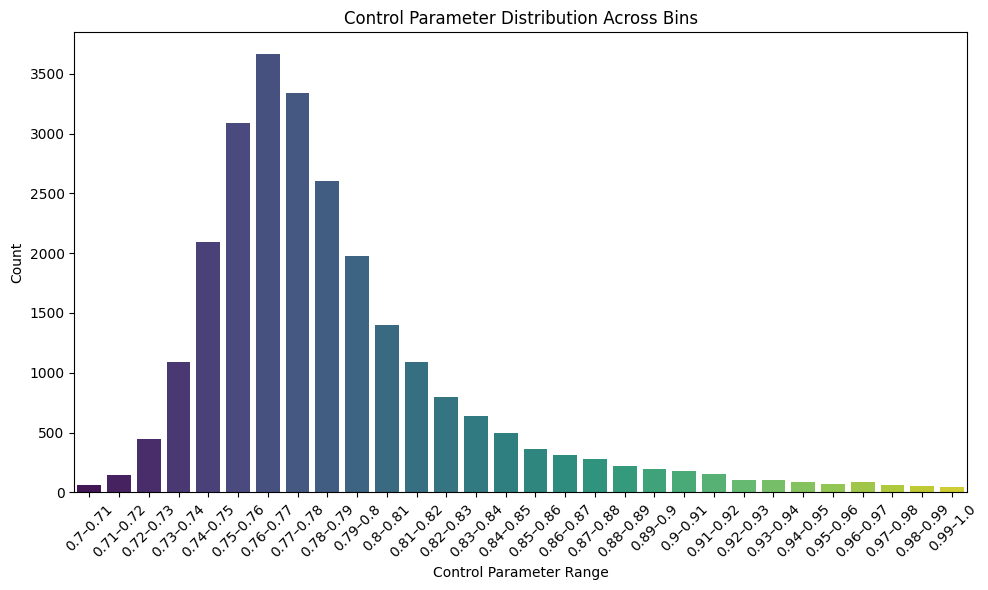

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

control_parameters  = df_with_control_parameter['control_parameter'].values
# probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# Create bins and labels
bins = np.arange(0.7, 1.0, 0.01)
labels = [f'{round(bins[i], 2)}–{round(bins[i+1], 2)}' for i in range(len(bins)-1)]

# Bin the data
binned_control_parameters = pd.cut(control_parameters, bins=bins, labels=labels, include_lowest=True)

# Create a DataFrame for plotting
df = pd.DataFrame({'Control Parameter Range': binned_control_parameters})

# Plot using seabornon
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')
plt.title('Control Parameter Distribution Across Bins')
plt.xlabel('Control Parameter Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# df.value_counts()